Dataset: titanic_dataset.csv

- Numerical vs numerical: scatter plot, correlation
- Numerical vs categorical: boxplot, group statistics
- Categorical vs categorical: crosstab, countplot


In [1]:
%pip install -q pandas numpy seaborn matplotlib scipy


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)

In [3]:
df = pd.read_csv("titanic_dataset.csv")

In [4]:
df.shape

(891, 15)

In [5]:
df.isnull() # Check for missing values in the DataFrame
df.isnull().sum() # Count the number of missing values in each column of the DataFrame
print(df.isnull().sum()/len(df)*100) # Print the percentage of missing values in each column to identify which columns have missing data and how many missing values they contain

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64


In [6]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')

| Column        | Description                                        | Feature Type                |
|---------------|----------------------------------------------------|-----------------------------|
| survived      | Whether the passenger survived (1) or not (0)      | Numerical (binary)          |
| pclass        | Passenger travel class (1, 2, 3)                   | Numerical (categorical encoded) |
| sex           | Passenger gender                                   | Categorical                 |
| age           | Passenger age in years                             | Numerical                   |
| sibsp         | Number of siblings or spouses aboard               | Numerical                   |
| parch         | Number of parents or children aboard               | Numerical                   |
| fare          | Ticket fare paid                                   | Numerical                   |
| embarked      | Port where passenger boarded (C, Q, S)             | Categorical                 |
| class         | Passenger class label (First, Second, Third)       | Categorical                 |
| who           | Person type (man, woman, child)                    | Categorical                 |
| adult_male    | Whether passenger is an adult male (True or False) | Categorical (boolean)       |
| deck          | Deck letter where cabin is located                 | Categorical                 |
| embark_town   | Town corresponding to embark point                 | Categorical                 |
| alive         | Survival status (yes or no) (repeated)             | Categorical                 |
| alone         | Whether the passenger traveled alone               | Categorical (boolean)       |

In [7]:
# Identify numerical and categorical features
num_cols = ["age", "fare", "sibsp", "parch"]
cat_cols = ["survived", "pclass", "sex", "embarked", "class", "who", "adult_male", "deck", "embark_town", "alone"]

print("\nNumerical columns:", num_cols)
print("Categorical columns:", cat_cols)


Numerical columns: ['age', 'fare', 'sibsp', 'parch']
Categorical columns: ['survived', 'pclass', 'sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alone']


In [8]:
df_num = df[num_cols].dropna()

In [9]:
df_num.head()

,age,fare,sibsp,parch
0,22.0,7.2500,1,0
1,38.0,71.2833,1,0
2,26.0,7.9250,0,0
3,35.0,53.1000,1,0
4,35.0,8.0500,0,0


In [10]:
df["survived_label"] = df["survived"].map({0: "No", 1: "Yes"})

In [11]:
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,survived_label
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,No
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,Yes
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,Yes
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,Yes
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,No


### 3. Numerical vs Numerical

**3.1. Scatter Plot**

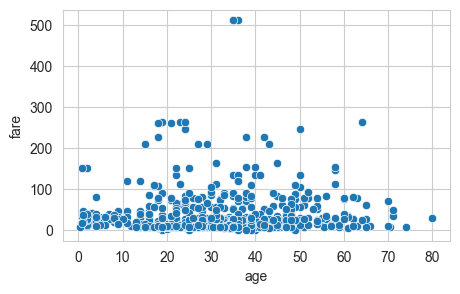

In [12]:
plt.figure(figsize=(5,3))
sns.scatterplot(x=df["age"], y=df["fare"])
plt.xlabel("age")
plt.ylabel("fare")
plt.show()

evenly distributed, no correlation


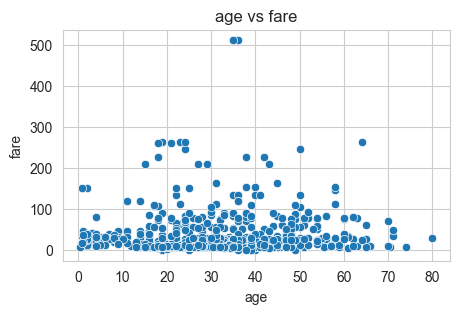

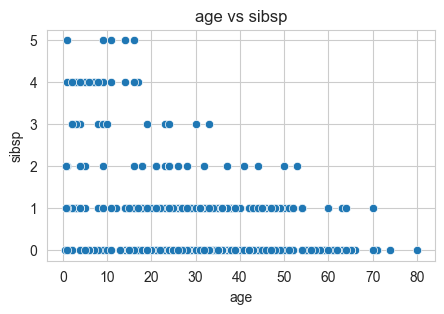

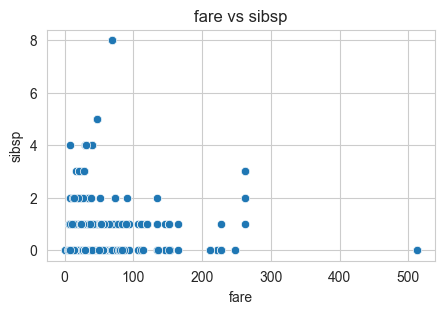

In [13]:
num_pairs = [
    ("age", "fare"),
    ("age", "sibsp"),
    ("fare", "sibsp")
]

for x, y in num_pairs:
    plt.figure(figsize=(5,3))
    sns.scatterplot(x=df[x], y=df[y])
    plt.title(f"{x} vs {y}")
    plt.xlabel(x)
    plt.ylabel(y)
    plt.show()

**3.2. Correlation Matrix**

In [14]:
print("Correlation Matrix")
df_num.corr()

# -1 -> high negative correlation; +1 -> high positive correlation

Correlation Matrix


,age,fare,sibsp,parch
age,1.000000,0.096067,-0.308247,-0.189119
fare,0.096067,1.000000,0.138329,0.205119
sibsp,-0.308247,0.138329,1.000000,0.383820
parch,-0.189119,0.205119,0.383820,1.000000


**Pearson Correlation**

- Measures linear association between two continuous variables. The coefficient `r` ranges from -1 to +1.
- Interpretation: magnitude indicates strength; sign indicates direction. A small p-value (e.g. < 0.05) suggests the observed correlation is unlikely under the null hypothesis `r=0`.
- Cautions: assumes approximate linearity and is sensitive to outliers; correlation does not imply causation.

Below we compute Pearson `r` and `p` between each numerical feature and `fare`, and print a short interpretation for the `age` vs `fare` result.

In [15]:
print("Pearson Correlation with fare:")
for col in num_cols:
    if col != "fare":
        r, p = pearsonr(df_num[col], df_num["fare"])
        print(f"{col} vs fare: r={r:.3f}; p={p:.3f}")

# r, p; r -> correlation coefficient (-1 to +1); p -> small val (0.05) -> strong confidence; high -> random coincidence 

Pearson Correlation with fare:
age vs fare: r=0.096; p=0.010
sibsp vs fare: r=0.138; p=0.000
parch vs fare: r=0.205; p=0.000


### 4. Numerical vs Categorical Features

**4.1. Boxplots**

**Box Plot (Boxplot)**

- A box plot visualizes the distribution of a numerical variable grouped by a categorical variable. It shows the median (center line), interquartile range (IQR, box), and whiskers (range excluding outliers).
- Useful to compare distributions, detect skewness, and spot outliers across categories.
- Interpretation: non-overlapping boxes or different medians suggest differences between groups; wide boxes indicate high dispersion.

Below is a corrected example plotting `age` by `survived_label`.

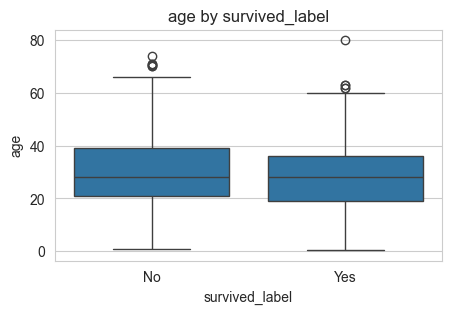

In [16]:
plt.figure(figsize=(5,3))
sns.boxplot(x=df["survived_label"], y=df["age"])
plt.xlabel("survived_label")
plt.ylabel("age")
plt.title("age by survived_label")
plt.show()

**Mean vs Median (overlay)**

- The boxplot shows the median (center line) and IQR (box). The mean is sensitive to outliers and is not shown by default.


Median: Shown as the center line in the box (50th percentile).

Mean: Not shown by default and is sensitive to outliers.

Skewness rule:

mean > median: right (positive) skew (tail to the right).

mean < median: left (negative) skew (tail to the left).

mean ≈ median: roughly symmetric distribution.

Robustness: Median is robust to outliers; mean is pulled toward extremes.

Practical check: If the median line is off-center inside the box or whiskers are asymmetric, expect mean ≠ median.

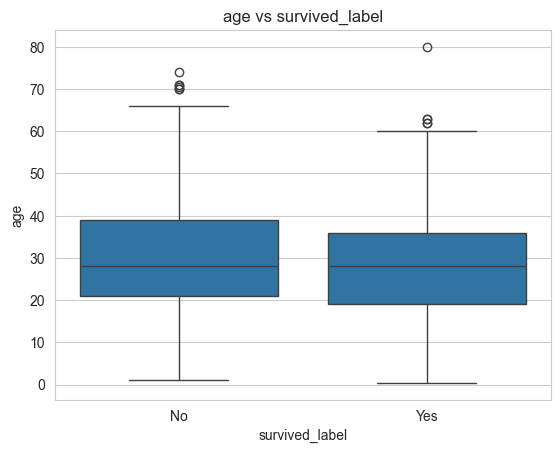

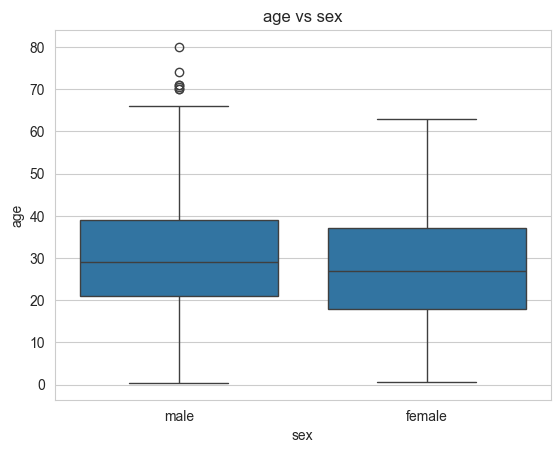

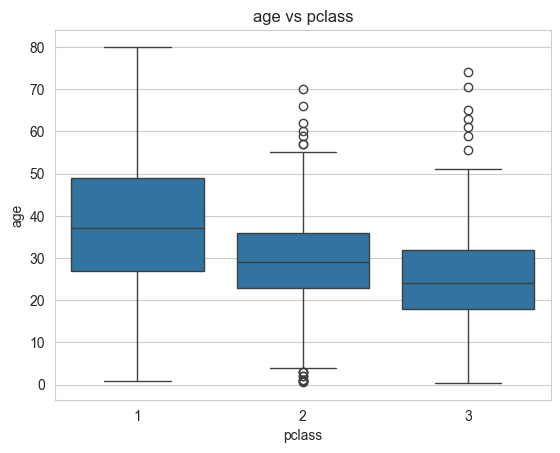

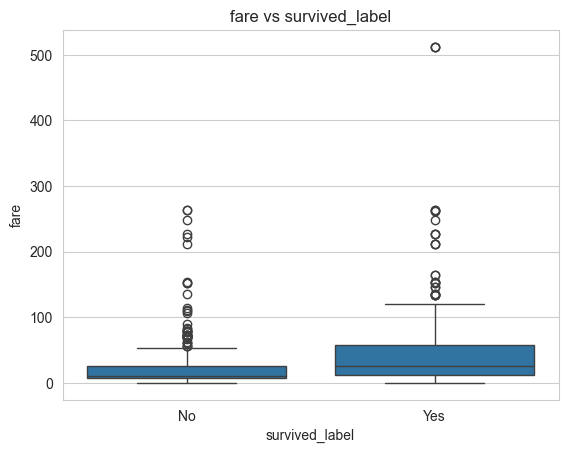

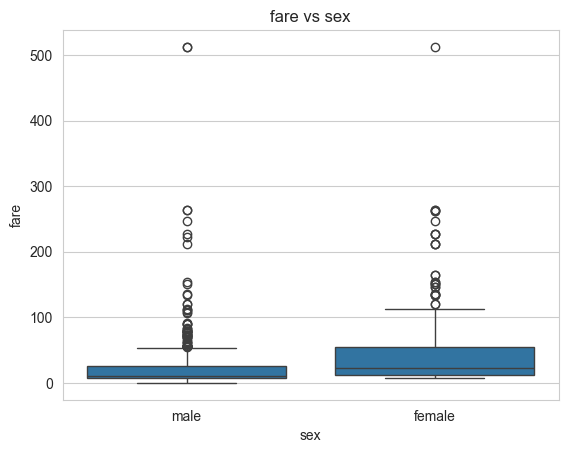

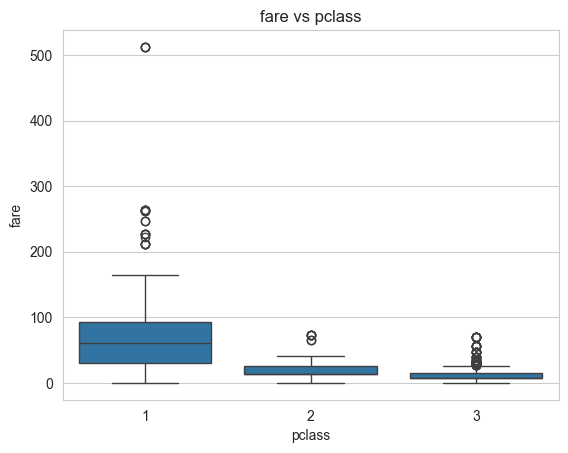

In [17]:
num_for_box = ["age", "fare"]
cat_for_box = ["survived_label", "sex", "pclass"]

for num in num_for_box:
    for cat in cat_for_box:
        plt.Figure(figsize=(5,3))
        sns.boxplot(x=df[cat], y=df[num])
        plt.title(f"{num} vs {cat}")
        plt.xlabel(cat)
        plt.ylabel(num)
        plt.show()

**4.2. Grouped Statistics**

In [18]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,survived_label
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,No
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,Yes
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,Yes
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,Yes
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,No


In [19]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone', 'survived_label'],
      dtype='str')

In [20]:
df[num_cols + ["survived_label"]]

,age,fare,sibsp,parch,survived_label
0,22.0,7.2500,1,0,No
1,38.0,71.2833,1,0,Yes
2,26.0,7.9250,0,0,Yes
3,35.0,53.1000,1,0,Yes
4,35.0,8.0500,0,0,No
...,...,...,...,...,...
886,27.0,13.0000,0,0,No
887,19.0,30.0000,0,0,Yes
888,NaN,23.4500,1,2,No
889,26.0,30.0000,0,0,Yes


In [21]:
df[num_cols + ["survived_label"]].groupby("survived_label").mean()

,age,fare,sibsp,parch
survived_label,,,,
No,30.626179,22.117887,0.553734,0.329690
Yes,28.343690,48.395408,0.473684,0.464912


In [22]:
for cat in ["survived_label", "sex", "pclass"]:
    print(f"Grouped Statistics for fare by {cat}:")
    # print(df.groupby(cat)["fare"].describe())
    print(df.groupby(cat)["fare"].mean())
    print("-"*50)

Grouped Statistics for fare by survived_label:
survived_label
No     22.117887
Yes    48.395408
Name: fare, dtype: float64
--------------------------------------------------
Grouped Statistics for fare by sex:
sex
female    44.479818
male      25.523893
Name: fare, dtype: float64
--------------------------------------------------
Grouped Statistics for fare by pclass:
pclass
1    84.154687
2    20.662183
3    13.675550
Name: fare, dtype: float64
--------------------------------------------------


### 5. Categorical vs Categorical features

**5.1. Crosstab examples**

In [23]:
print("Crosstab: sex vs survived")
print(pd.crosstab(df["sex"], df["survived_label"]))
print("-"*50)
print("Crosstab: pclass vs survived")
print(pd.crosstab(df["pclass"], df["survived_label"]))

Crosstab: sex vs survived
survived_label   No  Yes
sex                     
female           81  233
male            468  109
--------------------------------------------------
Crosstab: pclass vs survived
survived_label   No  Yes
pclass                  
1                80  136
2                97   87
3               372  119


**5.2. Countplot**

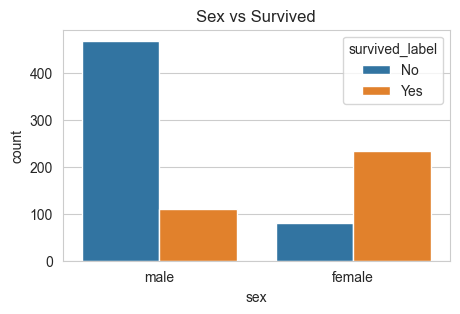

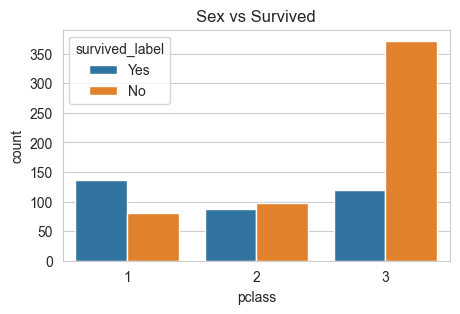

In [24]:
plt.figure(figsize=(5,3))
sns.countplot(x=df["sex"], hue=df["survived_label"])
plt.title("Sex vs Survived")
plt.show()


plt.figure(figsize=(5,3))
sns.countplot(x=df["pclass"], hue=df["survived_label"])
plt.title("Sex vs Survived")
plt.show()

### Summary

In [25]:
print("\nBivariate Analysis Completed")
print("- Numerical vs numerical: scatter + correlations")
print("- Numerical vs categorical: boxplots + group stats")
print("- Categorical vs categorical: crosstab + countplot")


Bivariate Analysis Completed
- Numerical vs numerical: scatter + correlations
- Numerical vs categorical: boxplots + group stats
- Categorical vs categorical: crosstab + countplot


**Key findings - Bivariate Analysis:**

Bivariate analysis shows how features interact with each other and reveals patterns that single feature analysis cannot capture.

- Numerical relationships are mostly weak, with low correlation values. This means age, fare, sibsp, and parch behave independently and do not cause multicollinearity.
- Fare strongly interacts with survival, sex, and class, making it an important predictive feature.
- Passenger class, sex, and embarked categories show clear separation in survival outcomes. These categorical interactions will be captured strongly by tree models.
- Grouped statistics show survival increases with higher fare and better travel class, reinforcing socioeconomic influence.
- Crosstabs highlight the strongest categorical drivers, especially sex and pclass.

Overall, bivariate analysis helps us confirm which pairs of features are most informative, guides feature engineering, and reveals the interactions that will matter most in machine learning models.

### **8.5. Multivariate Analysis**

- pairplot
- correlation Heatmap
- Cluster map
- Interaction and sub-group pattern discovery


## 6. Plots

**6.1. Pairplot**
What: A grid of scatterplots for every pair of numerical variables plus univariate plots on the diagonal. Shows pairwise relationships and marginal distributions.

When to use: Quick multivariate overview, spot correlations, clusters, outliers, and class separation (with hue).

Tips:

Use hue for a categorical label to see class separation.

Use corner=True to keep only the lower triangle (avoid duplicates).

Use diag_kind='kde' or 'hist' for diagonal plots.

For large datasets, sample rows to keep it fast/clear.

In [26]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,survived_label
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,No
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,Yes
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,Yes
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,Yes
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,No


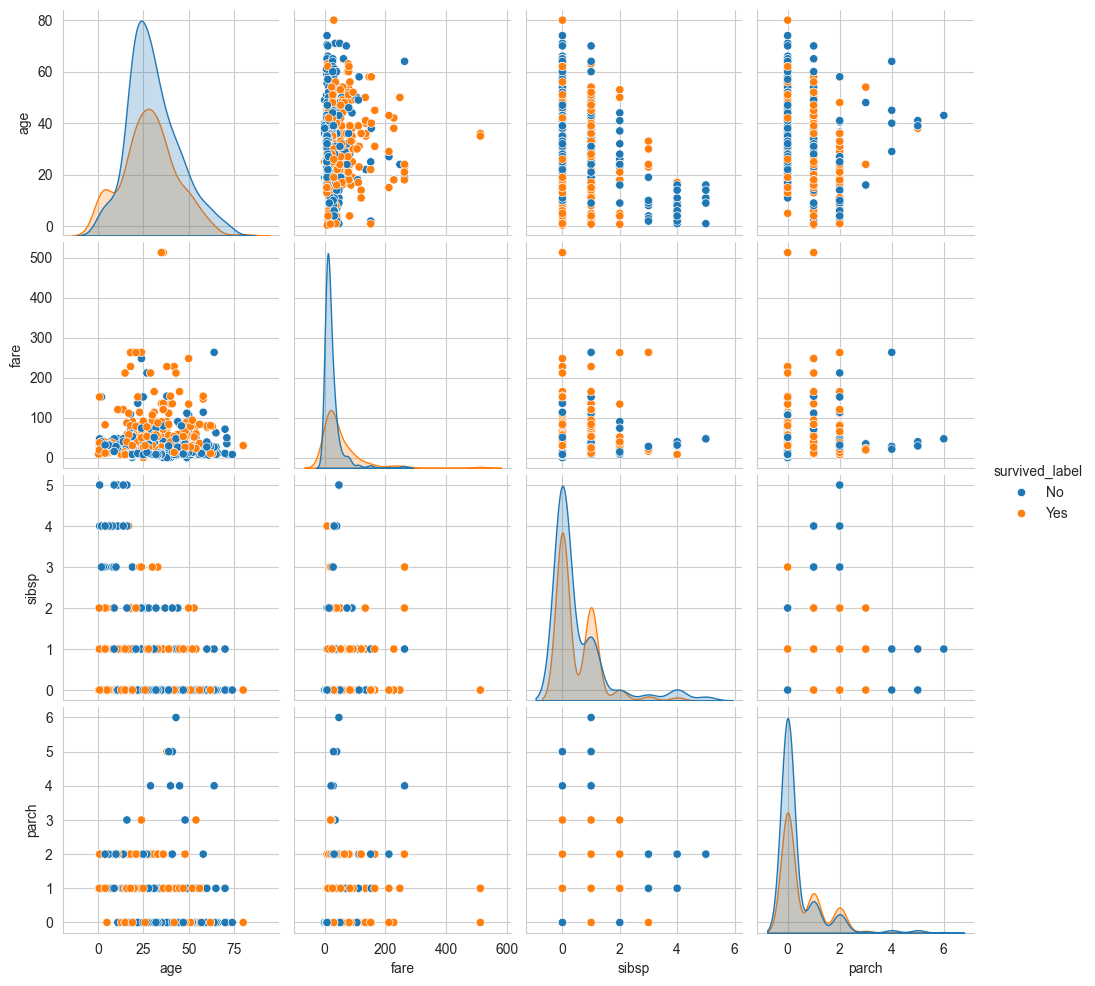

In [27]:
pairplot_cols = num_cols + ["survived_label"]

df_pair = df[pairplot_cols].dropna()

sns.pairplot(df_pair, hue="survived_label")
plt.show()

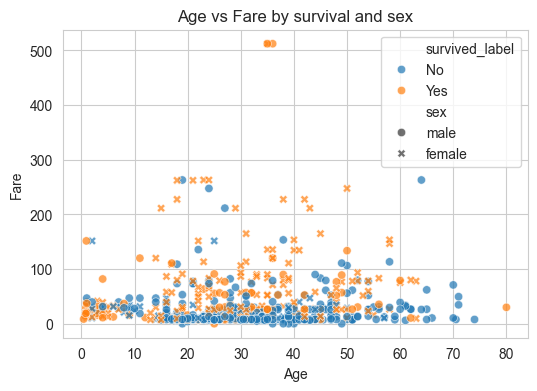

In [28]:
# age vs fare with survival & sex
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df,
    x="age",
    y="fare",
    hue="survived_label",
    style="sex",
    alpha=0.7
)
plt.title("Age vs Fare by survival and sex")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

**6.2. Correlation Heatmap**

In [31]:
df_num.head()

,age,fare,sibsp,parch
0,22.0,7.2500,1,0
1,38.0,71.2833,1,0
2,26.0,7.9250,0,0
3,35.0,53.1000,1,0
4,35.0,8.0500,0,0


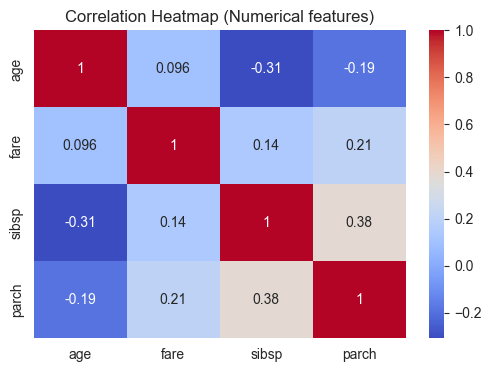

In [30]:
plt.figure(figsize=(6,4))
sns.heatmap(df_num.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Numerical features)")
plt.show()

**6.3. Cluster Map**

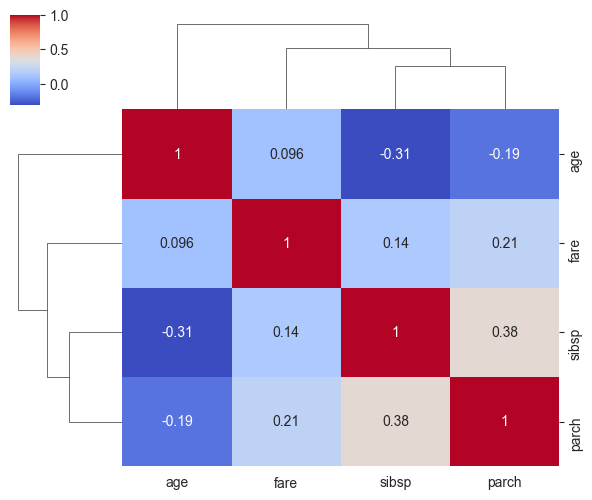

In [32]:
sns.clustermap(df_num.corr(), annot=True, cmap="coolwarm", figsize=(6,5))
plt.show()

### 7. Interaction & Sub-group Pattern

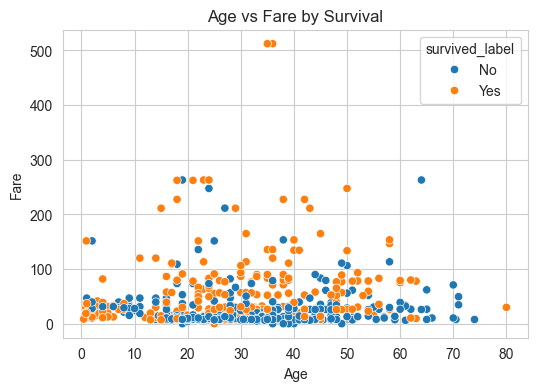

In [33]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["age"], y=df["fare"], hue=df["survived_label"])
plt.title("Age vs Fare by Survival")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

**7.2. Sub-groups: siblings/spouses**

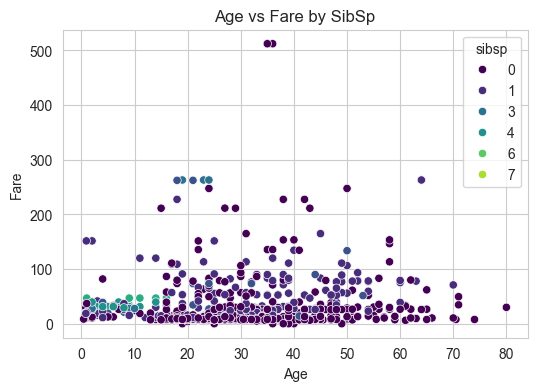

In [34]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["age"], y=df["fare"], hue=df["sibsp"], palette="viridis")
plt.title("Age vs Fare by SibSp")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

### **8. Summary**

In [35]:
print("- Multivariate: pairplot, heatmap, cluster map")
print("- Interaction and subgroup patterns plotted")

- Multivariate: pairplot, heatmap, cluster map
- Interaction and subgroup patterns plotted


**Key findings - Multivariate Analysis:**

Multivariate analysis helps uncover patterns that appear only when considering several variables together.

- Pairplots show strong interaction between fare, class, and survival, confirming that socioeconomic status is a dominant factor in survival prediction.

- Heatmaps and cluster maps reveal natural grouping of family related features (sibsp and parch) and independence of features like age.

- Interaction plots show survival patterns more clearly when combining variables such as age, fare, and family size.

- Multivariate visuals highlight the importance of engineered features, especially family_size, is_alone, and class based transformations.

- Survival clusters (high fare, lower sibsp, adult females) become visually obvious only in multivariate views.

Overall, multivariate analysis gives a deeper understanding of the feature interactions that machine learning models will pick up, guiding us toward better feature engineering and model design.